# Trend's Not Dead

https://www.cmegroup.com/content/dam/cmegroup/education/files/trends-not-dead-babbedge-kerson-2019.pdf

# Packages

In [1]:
import os
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
blog_path = os.getcwd()
res_path  = os.path.abspath(os.path.join(blog_path, ".."))
repo_path = os.path.abspath(os.path.join(res_path, ".."))
data_path = os.path.join(repo_path, "data")

In [3]:
path = os.path.join(data_path, "TrendIndices", "TrendIndicesGuide.xlsx")
df_ticker = (pd
    .read_excel(
        io         = path, 
        sheet_name = "TrendIndices")
    .rename(columns = {
        "Ticker"     : "ticker",
        "Asset Class": "asset_class"}))

# Getting Trend Indices

In [4]:
path = os.path.join(data_path, "TrendIndices", "RawTrendIndices.parquet")
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .rename(columns = {"security": "ticker"}))

In [5]:
def _get_desc_stat(df: pd.DataFrame) -> pd.DataFrame: 

    sharpe = (df
        [["rtn"]]
        .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
        .item())

    df_out = (df
        [["date"]]
        .agg(["min", "max"])
        .T
        .assign(sharpe = sharpe))

    return df_out

gfc_date = dt.date(year = 2009, month = 3, day = 1)

df_prep = (df_raw
    .set_index("date")
    .groupby("ticker")
    .apply(lambda x: x.sort_index().pct_change())
    .rename(columns = {"PX_LAST": "rtn"})
    .reset_index()
    .assign(
        date       = lambda x: pd.to_datetime(x.date).dt.date,
        date_group = lambda x: np.where(x.date <= gfc_date, "before_gfc", "after_gfc"),
        group_var  = lambda x: x.date_group + "-" + x.ticker))

df_stat = (df_prep
    .groupby("group_var")
    .apply(_get_desc_stat)
    .reset_index()
    .drop(columns = ["level_1"])
    .rename(columns = {
        "min": "start_date",
        "max": "end_date"})
    .assign(
        date_group = lambda x: x.group_var.str.split("-").str[0],
        ticker     = lambda x: x.group_var.str.split("-").str[1])
    .drop(columns = ["group_var"]))

In [6]:
df_sharpe = (df_stat
    .assign(
        start_date = lambda x: pd.to_datetime(x.start_date),
        end_date   = lambda x: pd.to_datetime(x.end_date),
        years      = lambda x: (x.end_date - x.start_date).dt.days / 360)
    .drop(columns = ["start_date", "end_date"])
    .melt(id_vars = ["date_group", "ticker"])
    .assign(name = lambda x: x.date_group + "_" + x.variable)
    .pivot(index = "ticker", columns = "name", values = "value")
    .dropna())

In [7]:
sharpe_ols = (sm
    .OLS(
        endog = df_sharpe.after_gfc_sharpe,
        exog  = sm.add_constant(df_sharpe.before_gfc_sharpe))
    .fit())

In [8]:
param_dict = sharpe_ols.params.to_dict()

In [9]:
x = (np
    .linspace(
        start = df_sharpe.before_gfc_sharpe.min(),
        stop  = df_sharpe.before_gfc_sharpe.max(),
        num   = 1_000))

y = (x * param_dict["before_gfc_sharpe"]) + param_dict["const"]

They begin by analyzing the performance of trend before and after 2008. They has been a noticeable shapre reduction post 2008. To test this start by regressing pre-2008 to post-2008 sharpes against each other. Although they represent different times they provide a rough estimate. The closer the $\beta$ is to 1 the stronger the case is for consistent returns. If the $\beta < 1$ then that implies that there has been a decrease in sharpe post 2009. 

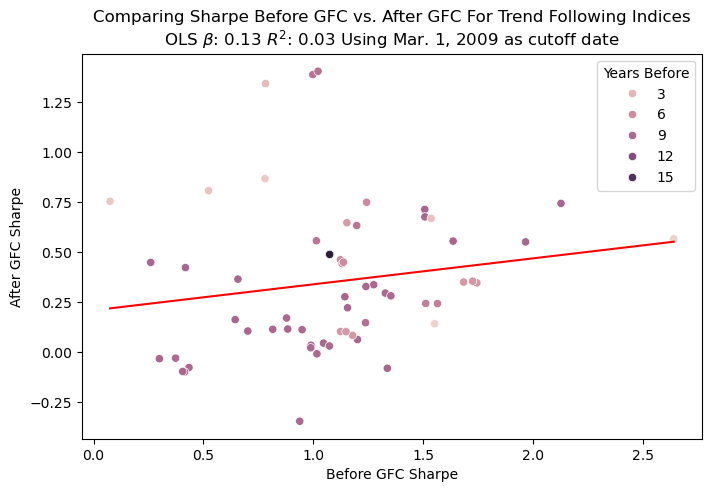

In [10]:
df_plot = (df_sharpe
    .rename(columns = {"before_gfc_years": "Years Before"}))

fig, axes = plt.subplots(figsize = (8,5))

(sns
    .scatterplot(
        ax   = axes,
        data = df_plot,
        x    = "before_gfc_sharpe",
        y    = "after_gfc_sharpe",
        hue  = "Years Before"))

axes.plot(
    x,
    y,
    color = "red")

axes.set_xlabel("Before GFC Sharpe")
axes.set_ylabel("After GFC Sharpe")
axes.set_title(
    "Comparing Sharpe Before GFC vs. After GFC For Trend Following Indices\n" +  r"OLS $\beta$: {} $R^2$: {} Using Mar. 1, 2009 as cutoff date"
    .format(np.round(param_dict["before_gfc_sharpe"], 2), np.round(sharpe_ols.rsquared, 2)))

plt.show()

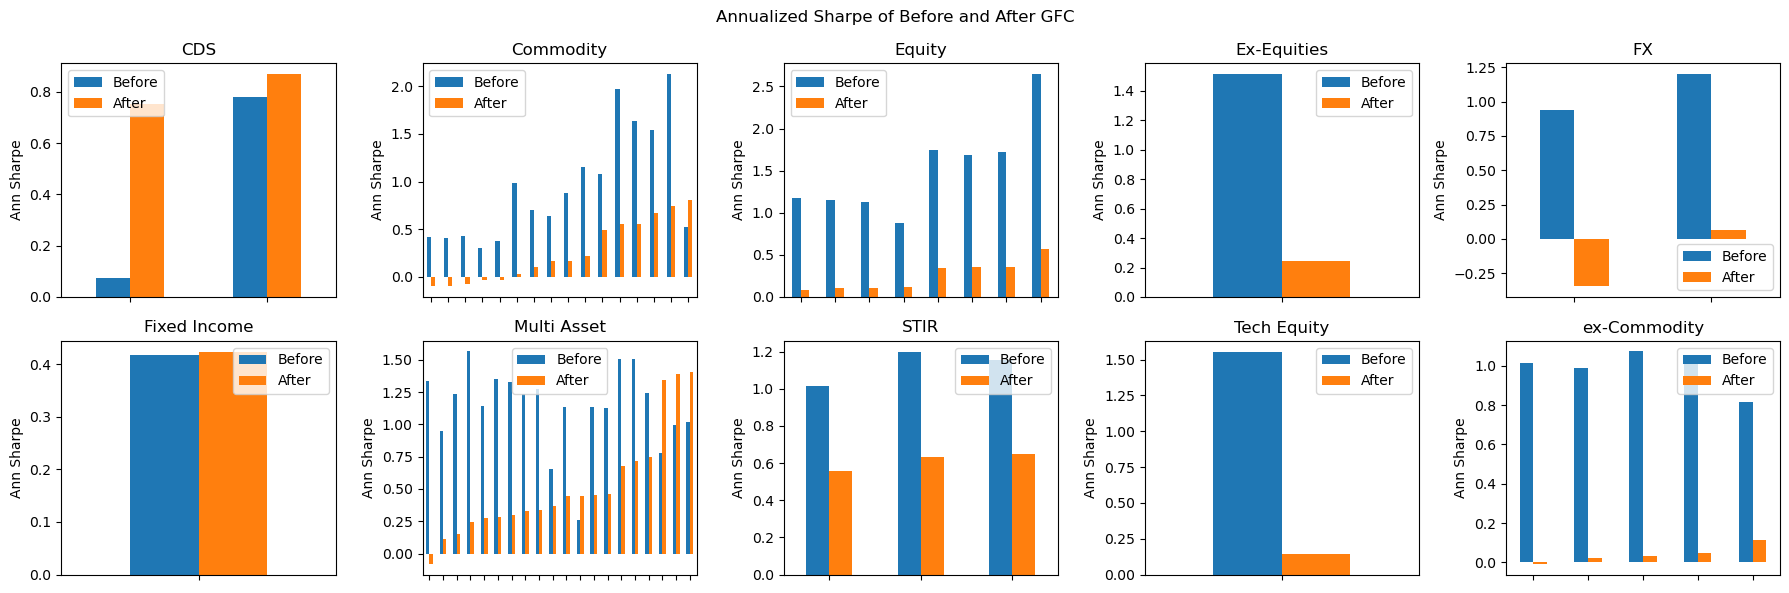

In [11]:
df_compare_prep = (df_sharpe
    .reset_index()
    .merge(right = df_ticker, how = "inner", on = ["ticker"]))

asset_classes = df_compare_prep.asset_class.drop_duplicates().sort_values().to_list()
fig, axes     = plt.subplots(ncols = len(asset_classes) // 2, nrows = 2, figsize = (18,6))

for asset_class, ax in zip(asset_classes, axes.flatten()): 

    (df_compare_prep
        .loc[lambda x: x.asset_class == asset_class]
        .assign(PlotName = "")
        .set_index("PlotName")
        [["before_gfc_sharpe", "after_gfc_sharpe"]]
        .sort_values("after_gfc_sharpe")
        .rename(columns = {
            "before_gfc_sharpe": "Before",
            "after_gfc_sharpe" : "After"})
        .plot(
            ax     = ax,
            kind   = "bar",
            xlabel = "",
            ylabel = "Ann Sharpe",
            title  = asset_class))

fig.suptitle("Annualized Sharpe of Before and After GFC")
plt.tight_layout()

# Measuring Cumulative Loss from Instantaneous Execution

They start by replicating the PnLs of trading instantaneously vs lagged (which is realistic). They propose if there was some sort of $\alpha$ decay then it would be realized through the difference in cumulative PnL of instantaneous vs lagged execution. They don't specifically state which futures contracts they use and how they construct their signal, in this case Dao et al. (2016), *Tail protection for long investors: Trend convexity at work*. <a href="https://arxiv.org/abs/1607.02410">arXiv</a>. approach is used since it has the highest correlation to Soc Gen Trend Following Indices. 

In [12]:
path = os.path.join(data_path, "Signals", "DaoNguyenDerembleLemperiereBouchaudPotters.parquet")
df_signal = (pd.read_parquet(path = path, engine = "pyarrow"))

In [13]:
path = os.path.join(data_path, "TrendIndices", "TrendIndicesGuide.xlsx")
df_idx_ticker = (pd
    .read_excel(io = path, sheet_name = "IndexReplication")
    .loc[lambda x: x.group == "TLDao"]
    .assign(ticker = lambda x: x.ticker.str.replace(" 1", "1").str.lower().str.replace(" ", "_")))

In [14]:
tickers = df_idx_ticker.ticker.drop_duplicates().sort_values().to_list()
df_signal_rtn = (df_signal
    .loc[lambda x: x.ticker.isin(tickers)]
    .assign(
        perf_rtn = lambda x: np.sign(x.signal) * x.px_rtn,
        lag_rtn  = lambda x: np.sign(x.lag_signal) * x.px_rtn)
    [["date", "ticker", "lag_rtn", "perf_rtn"]]
    .melt(id_vars = ["date", "ticker"])
    .dropna())

In [15]:
def _target_vol(df: pd.DataFrame, target: float = 0.1, vol_window: int = 100, threshold: float = 0.1) -> pd.DataFrame: 

    df_wider = (df
        .pivot(index = "date", columns = "ticker", values = "value"))

    df_perf = (df_wider
        .apply(lambda x: x * (target / (x.ewm(span = vol_window, adjust = False).std() * np.sqrt(252))))
        .apply(lambda x: np.where(np.abs(x) > threshold, np.nan, x))
        .reset_index()
        .melt(id_vars = "date", value_name = "rtn")
        .assign(vol = "perfect"))

    df_lagged = (df_wider
        .apply(lambda x: x * (target / (x.ewm(span = vol_window, adjust = False).std().shift() * np.sqrt(252))))
        .apply(lambda x: np.where(np.abs(x) > threshold, np.nan, x))
        .reset_index()
        .melt(id_vars = "date", value_name = "rtn")
        .assign(vol = "lagged"))

    df_out = pd.concat([df_perf, df_lagged])
    return df_out

df_target = (df_signal_rtn
    .groupby("variable")
    .apply(_target_vol)
    .reset_index()
    .drop(columns = ["level_1"]))

In [16]:
df_port = (df_target
    .drop(columns = ["ticker"])
    .groupby(["date", "variable", "vol"])
    .agg("mean")
    .reset_index())

In [17]:
df_spread = (df_port
    .assign(name = lambda x: x.variable + "_" + x.vol)
    .pivot(index = "date", columns = "name", values = "rtn")
    .assign(
        spread1 = lambda x:  x.lag_rtn_perfect - x.perf_rtn_lagged,
        spread2 = lambda x: x.lag_rtn_perfect - x.perf_rtn_perfect,
        spread3 = lambda x: x.lag_rtn_lagged - x.perf_rtn_lagged,
        spread4 = lambda x: x.lag_rtn_perfect - x.perf_rtn_lagged))

Contemporaneous and lagged volatility targeting is taken into consideration although regardless of which is used, the results are completeley the same. 

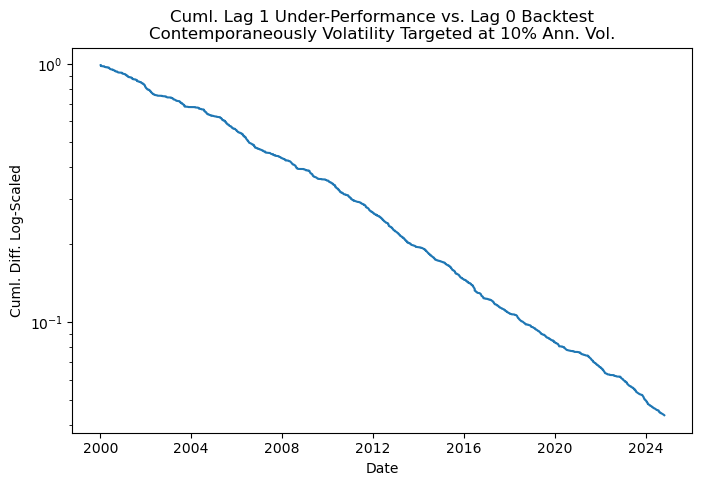

In [18]:
(df_spread
    [["spread2"]]
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        logy    = True,
        legend  = False,
        ylabel  = "Cuml. Diff. Log-Scaled",
        title   = "Cuml. Lag 1 Under-Performance vs. Lag 0 Backtest\nContemporaneously Volatility Targeted at 10% Ann. Vol.",
        xlabel  = "Date",
        figsize = (8,5)))

plt.show()

# Stock vs. Flow

The idea that they are trying to show is that CTAs can have the same position (stock), but that can lead to different changes in position (flow). They focus on measuring the effective speed for EWMACs (the math can be found in the appendix). They build two CTA signals that have 40-50 day effective speed. A rough estimation will work where the medium ~50d EWMAC will be EWMAC(20,80) and then a combination of fast and slow EWMAC will be $\frac{1}{2}$EWMAC(10,40) + $\frac{1}{2}$EWMAC(40,160)

In [19]:
df_cl = (df_signal
    .loc[lambda x: x.ticker == "cl1_comdty"]
    .set_index("date")
    [["px"]])

In [20]:
def make_similar_ewmac(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (df
        .assign(
            vol_adj = lambda x: x.px.ewm(span = 10, adjust = False).std(),
    
            # for medium window
            px20 = lambda x: x.px.ewm(span = 20, adjust = False).mean(),
            px80 = lambda x: x.px.ewm(span = 80, adjust = False).mean(),
        
            # for fast & slow windows
            px10  = lambda x: x.px.ewm(span = 10,  adjust = False).mean(),
            px40  = lambda x: x.px.ewm(span = 40,  adjust = False).mean(),
            px60  = lambda x: x.px.ewm(span = 60,  adjust = False).mean(),
            px160 = lambda x: x.px.ewm(span = 200, adjust = False).mean(),
    
            # create signals
            signal_a = lambda x: (x.px20 - x.px80) / x.px.diff().ewm(span = 80-20).std(),
            signal_b = lambda x: ((0.5 * (x.px10 - x.px40)) + (0.5 * (x.px40 - x.px160))) / x.px.diff().ewm(span = 15, adjust = False).std()
            ))

    return df_out

df_ewmac = make_similar_ewmac(df_cl)

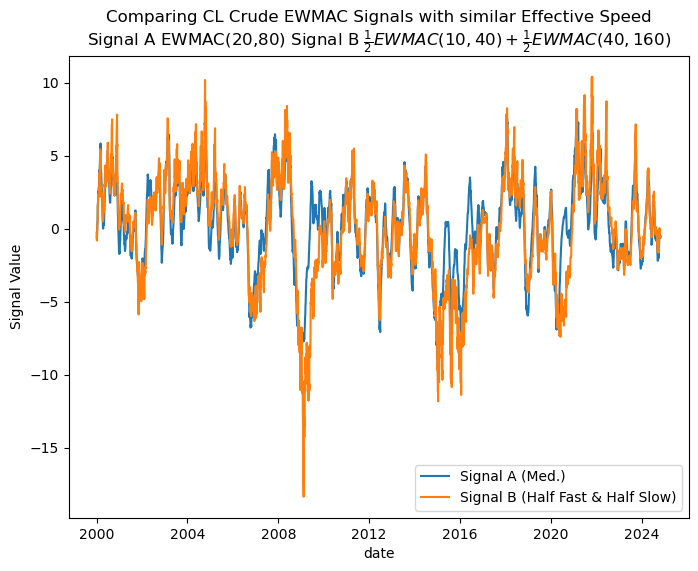

In [21]:
fig, axes = plt.subplots(figsize = (8,6))

(df_ewmac
    [["signal_a", "signal_b"]]
    .rename(columns = {
        "signal_a": "Signal A (Med.)",
        "signal_b": "Signal B (Half Fast & Half Slow)"})
    .plot(
        ylabel = "Signal Value",
        ax     = axes,
        title  = "Comparing CL Crude EWMAC Signals with similar Effective Speed\n" + r"Signal A EWMAC(20,80) Signal B $\frac{1}{2} EWMAC(10,40) + \frac{1}{2}EWMAC(40,160)$"))
plt.show()

In [22]:
stock_corr = (df_ewmac
    [["signal_a", "signal_b"]]
    .corr()
    .signal_a
    .iloc[1])

In [23]:
flow_corr = (df_ewmac
    [["signal_a", "signal_b"]]
    .diff()
    .corr()
    .signal_a
    .iloc[1])

<Axes: title={'center': 'Stock vs. Flow: Two Signals with similar effective speed\nwith different changes in signal Stock Corr: 0.87 Flow Corr: 0.71'}, xlabel='CTA Signal A', ylabel='CTA Signal B'>

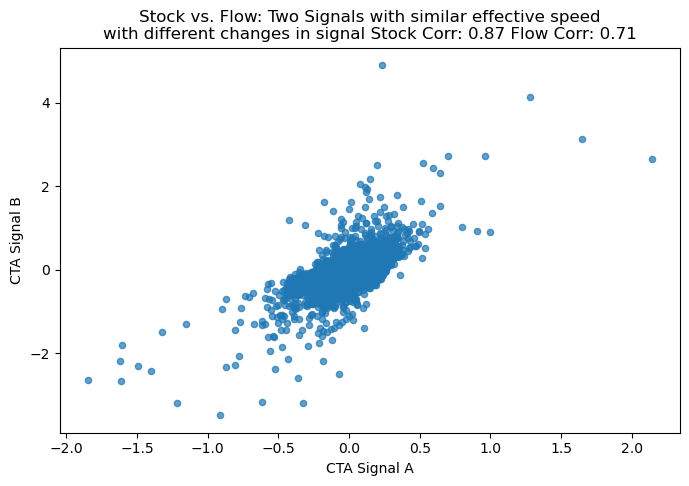

In [24]:
(df_ewmac
    [["signal_a", "signal_b"]]
    .diff()
    .plot(
        figsize = (8,5),
        kind    = "scatter", 
        x       = "signal_a",
        y       = "signal_b",
        xlabel  = "CTA Signal A",
        ylabel  = "CTA Signal B",
        alpha   = 0.7,
        title   = "Stock vs. Flow: Two Signals with similar effective speed\nwith different changes in signal Stock Corr: {} Flow Corr: {}".format(
            np.round(stock_corr,2),
            np.round(flow_corr, 2))))

# Appendix

Effective speed calculation. Start with a single EWMA window, and start with the original weight for any arbitrary day $k$
\begin{equation}
w_k = (1 - \lambda) \lambda^k
\end{equation}
Then to find the cumulative weight over the $N$ days is 
\begin{equation}
\sum_{k=0}^{N-1} (1-\lambda)\lambda^k = 1 - \lambda^N
\end{equation}
Then setting that condition that the weight must contain atleast 50% is the following condtion
\begin{equation}
1 - \lambda^N \geq 0.5
\end{equation}
Which ultimately becomes 
\begin{equation}
N \geq \frac{\ln(0.5)}{\ln(\lambda)}
\end{equation}
Then the next step is to expand this to two windows which results in the following
\begin{equation}
\sum_{k=0}^{N-1} (1 - \lambda_f) \lambda_f^k - (1 - \lambda_s) \lambda_s^k
\end{equation}
Then that becomes 
\begin{equation}
(1 - \lambda_f^N) - (1 - \lambda_s^N)
\end{equation}
Although that series converges towards since the weights converge towards 1 as $N$ gets larger
\begin{equation}
\lim_{n\rightarrow N} \lambda_s^N - \lambda_f^N = 0
\end{equation}
Therefore instead of the difference use the magnitude
\begin{equation}
w_k = |(1 - \lambda_f)\lambda_f^k - (1 - \lambda_s) \lambda_s^k|
\end{equation}
Then find the proprtion that contains more than half via 
\begin{equation}
0.5 \geq \frac{\sum_{k=0}^{N-1} |w_k|}{\sum_{k=0}^\infty |w_k|}
\end{equation}
which doesn't have a closed form solution